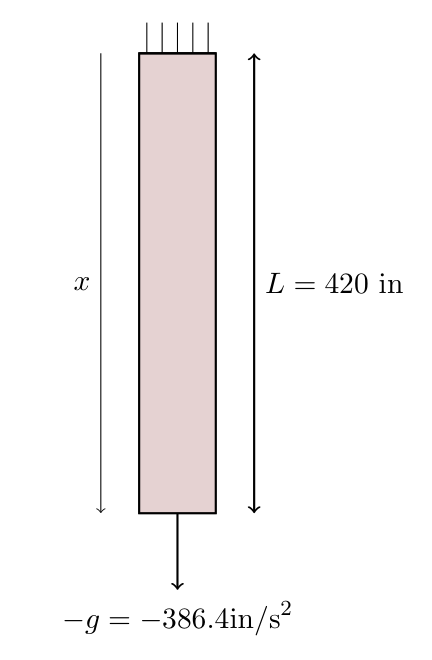

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem
from skrom.utils.visualization.color_palette import set_color_palette
# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

PETSc available: True


### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
import sci_mplstyle_package
set_color_palette();


## Full Order Simulation


In [4]:
# Control flag for expensive simulation generation

generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


Snap 1/64 params=[-3.17788620e+02  1.51996505e-02]
Snap 2/64 params=[70.69246098  0.28612272]
Snap 3/64 params=[5.63441208e+02 2.36026961e-01]
Snap 4/64 params=[-8.26169023e+02  4.63730467e-01]
Snap 5/64 params=[-5.46504397e+02  1.53488849e-01]
Snap 6/64 params=[7.83779662e+02 4.27982504e-01]
Snap 7/64 params=[2.91023305e+02 9.67306527e-02]
Snap 8/64 params=[-38.13160397   0.32068053]
Snap 9/64 params=[-135.41429117    0.18804861]
Snap 10/64 params=[382.46132061   0.48035797]
Snap 11/64 params=[8.89857551e+02 6.12130463e-02]
Snap 12/64 params=[-6.27194086e+02  2.71253704e-01]
Snap 13/64 params=[-9.69111253e+02  8.02746033e-02]
Snap 14/64 params=[7.31778275e+02 3.68525097e-01]
Snap 15/64 params=[2.24374434e+02 1.68041036e-01]
Snap 16/64 params=[-4.77339068e+02  3.82323606e-01]
Snap 17/64 params=[-3.98131667e+02  1.86364091e-01]
Snap 18/64 params=[151.02446266   0.39622163]
Snap 19/64 params=[6.42772816e+02 6.34433036e-02]
Snap 20/64 params=[-9.05498303e+02  3.55081288e-01]
Snap 21/64 pa

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_2_h\ROM_data


## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


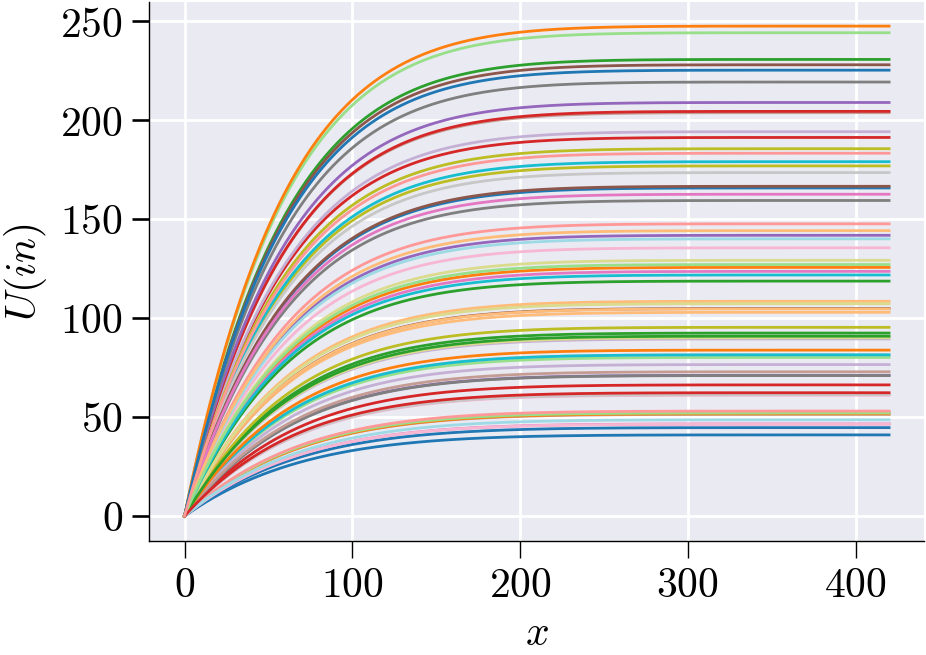

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$U (in)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

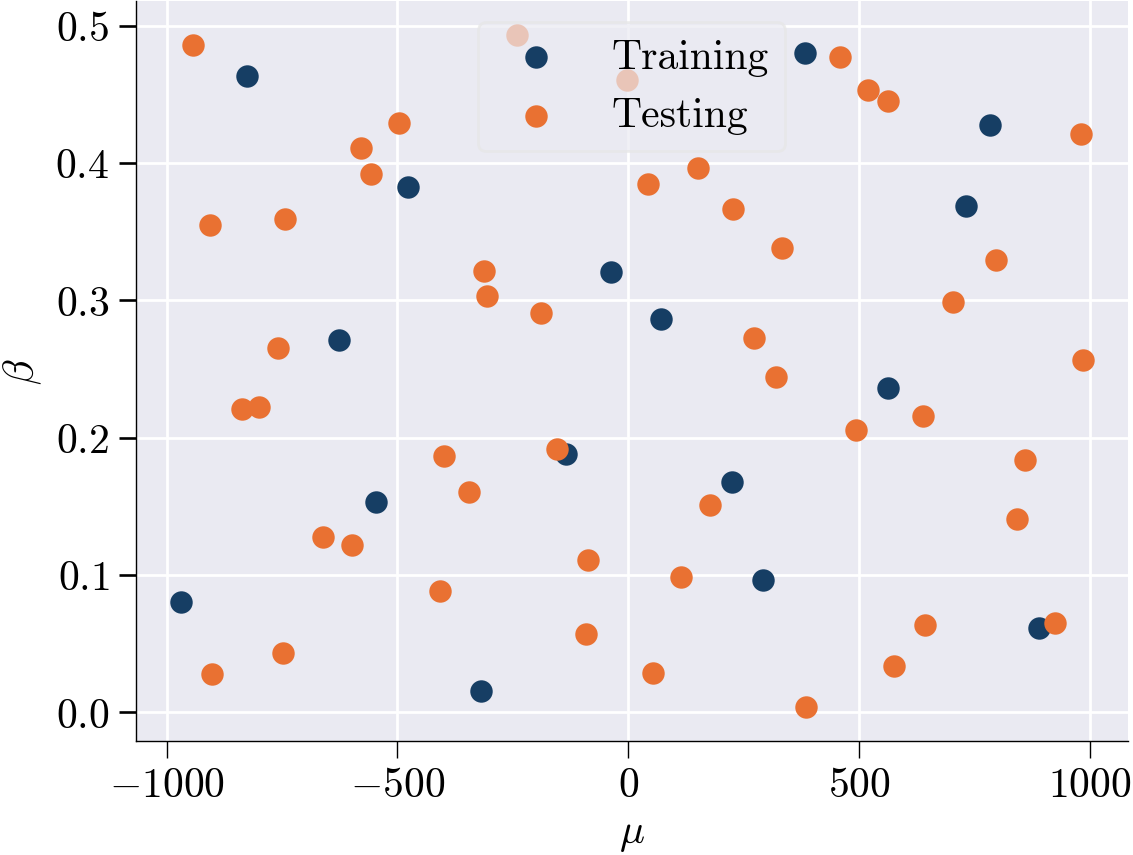

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

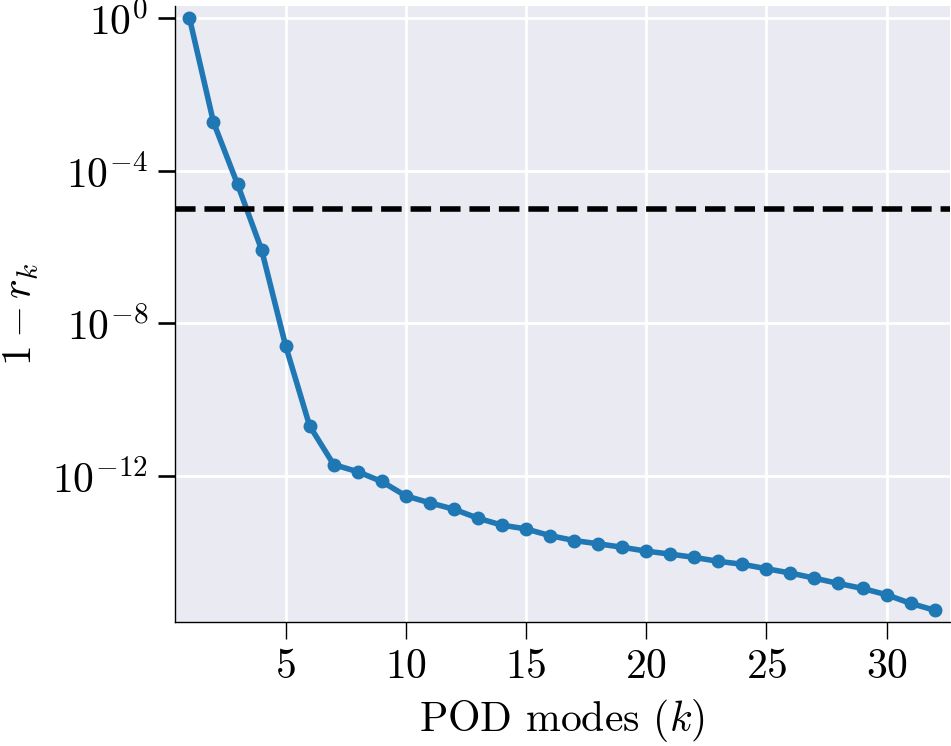

In [10]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-5,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [11]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_2_h\ROM_data


In [12]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[-5.97678427e+02  1.21865949e-01]
[Newton] Iter  0, step norm = 7.224e+03
[Newton] Iter  1, step norm = 2.566e+03
[Newton] Iter  2, step norm = 1.106e+03
[Newton] Iter  3, step norm = 5.158e+02
[Newton] Iter  4, step norm = 2.493e+02
[Newton] Iter  5, step norm = 1.226e+02
[Newton] Iter  6, step norm = 6.077e+01
[Newton] Iter  7, step norm = 3.026e+01
[Newton] Iter  8, step norm = 1.510e+01
[Newton] Iter  9, step norm = 7.541e+00
[Newton] Iter 10, step norm = 3.769e+00
[Newton] Iter 11, step norm = 1.884e+00
[Newton] Iter 12, step norm = 9.418e-01
[Newton] Iter 13, step norm = 4.709e-01
[Newton] Iter 14, step norm = 2.354e-01
[Newton] Iter 15, step norm = 1.177e-01
[Newton] Iter 16, step norm = 5.886e-02
[Newton] Iter 17, step norm = 2.943e-02
[Newton] Iter 18, step norm = 1.471e-02
[Newton] Iter 19, step norm = 7.357e-03
Snap 2/64 params=[42.63963364  0.38449691]
[Newton] Iter  0, step norm = 8.246e+03
[Newton] Iter  1, step norm = 6.416e+03
[Newton] Iter  2, step nor

In [13]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 1.7664e-03
Relative L2 Error:        6.3834e-07
L∞ Error:                 2.3223e-04
Relative L∞ Error:        9.3767e-07
RMSE:                     7.8060e-05
MAE:                      6.2936e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -7.8259e-06
95th Percentile Error:    1.4653e-04

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.5783e-08
Max Rel L2 Error over time/parameter: 4.7315e-08
Min Rel L2 Error over time/parameter: 1.5123e-08
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

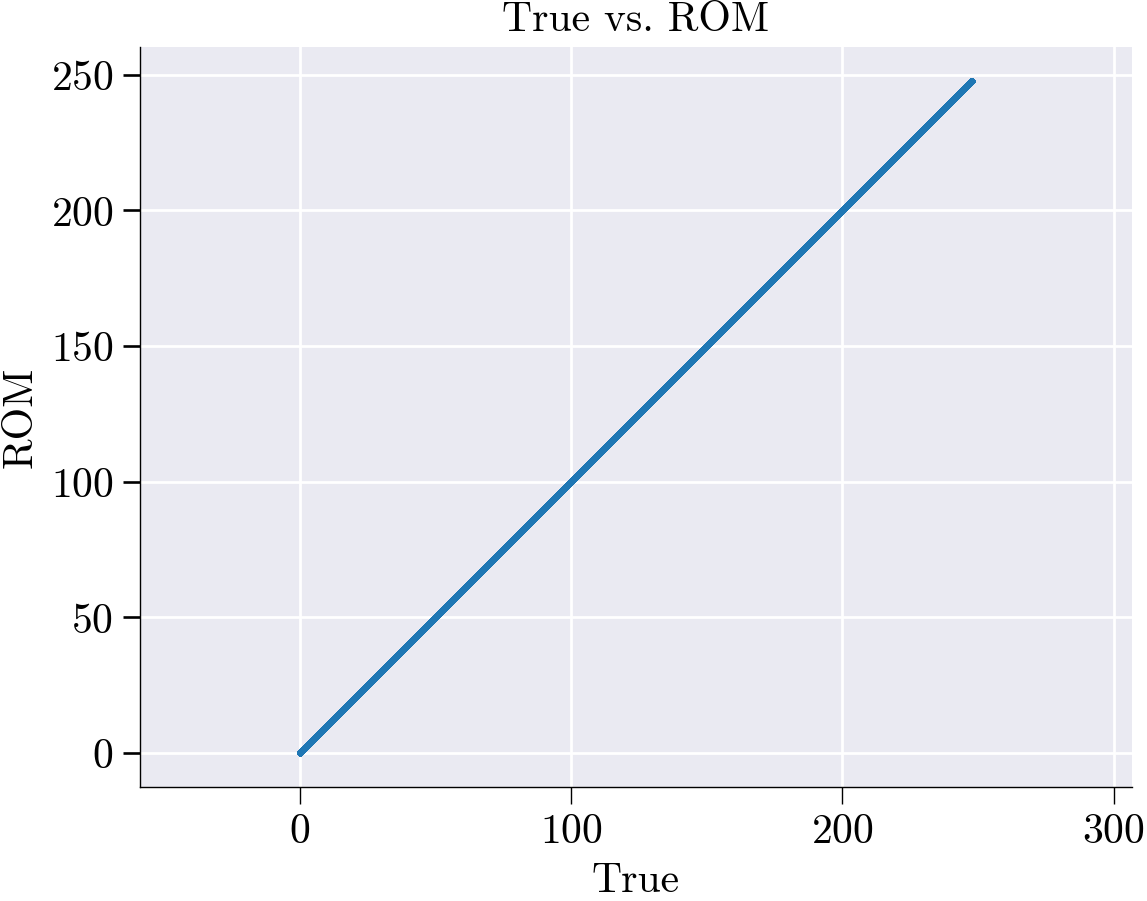

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


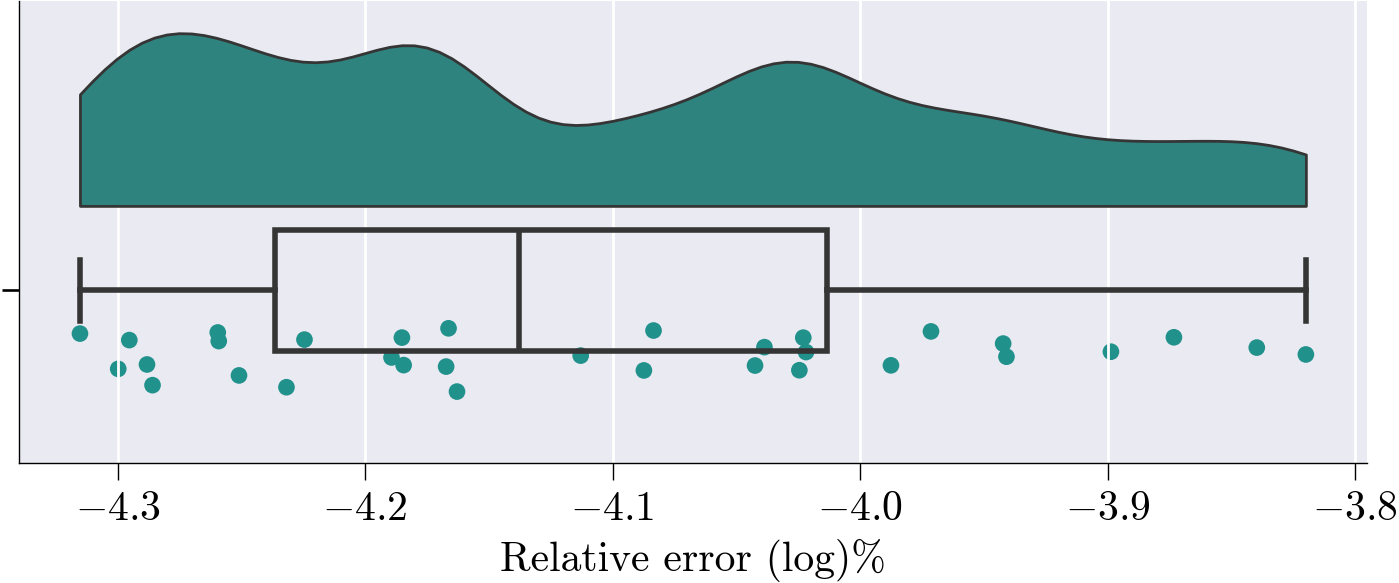

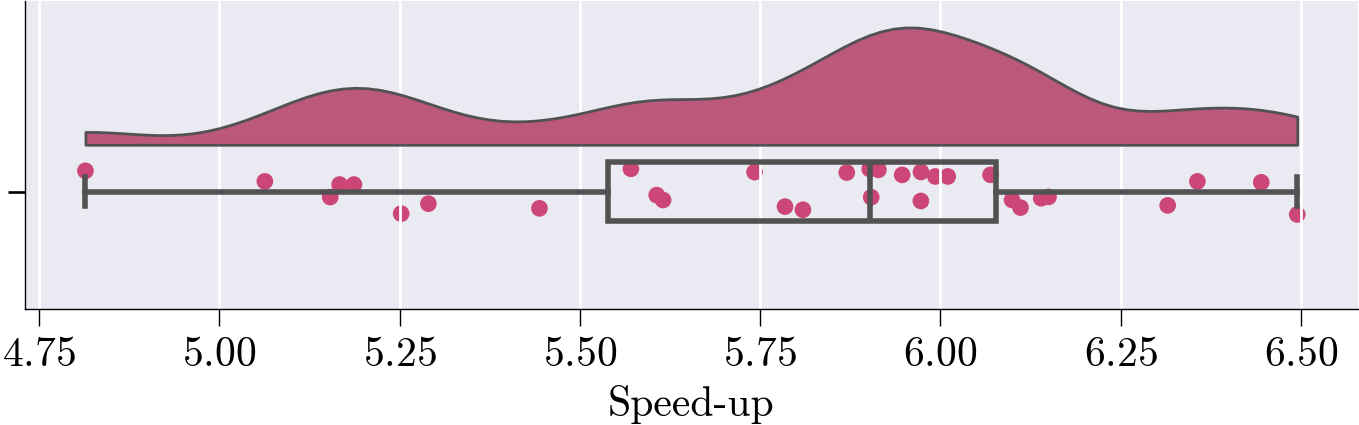

In [14]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [15]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_boundary_dofs']
free_dofs = prob.domain()['free_dofs']

In [16]:
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()

# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [17]:
q_mus = collect_residuals(
    NLS_train_ms,
    NLS_train_mean,
    V_sel,
    reconstruct_solution,
    Residual,
    training_params,
    prob.assemble_kwargs,  
)
print(q_mus.shape)

(128, 16384)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 127.99459000645585


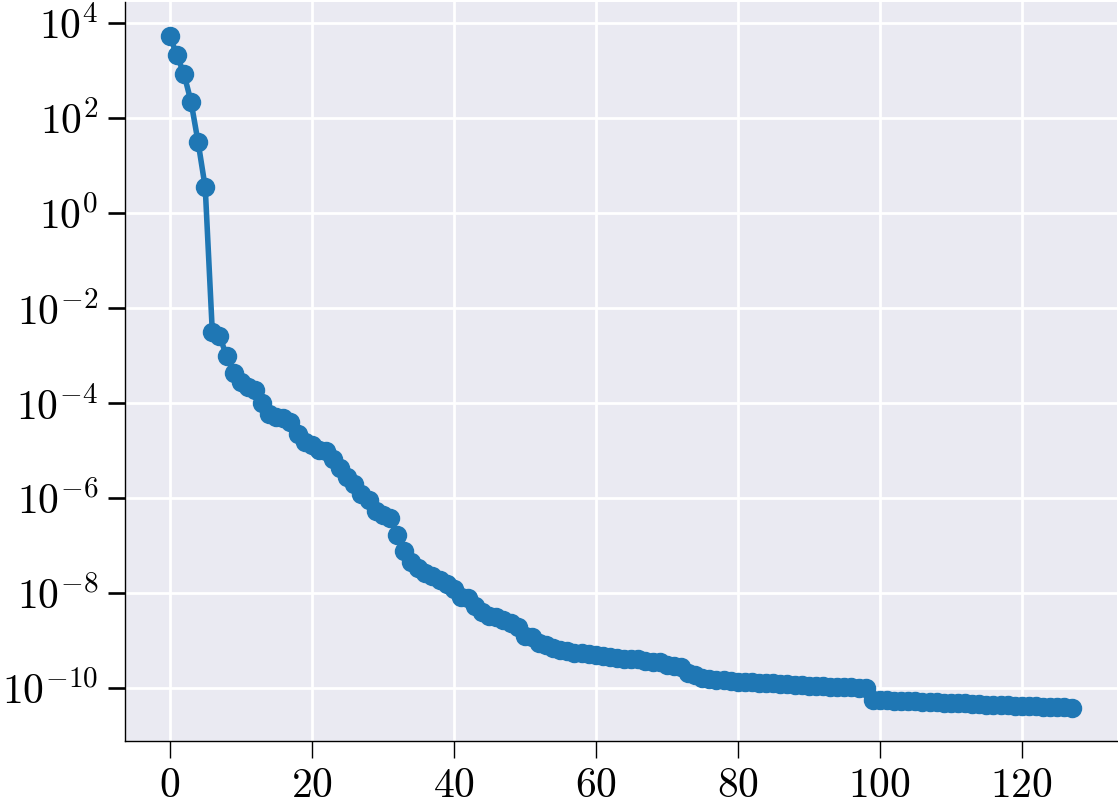

In [18]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:100]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [19]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 16384 0 9.661935107264340e+01 1.279945900064559e+02
1 1 100 16384 1 9.650463822530659e+01 1.279713191487557e+02
2 2 100 16384 2 9.640189196788101e+01 1.279319790110141e+02
3 3 100 16384 3 9.646560861113136e+01 1.279211075416267e+02
4 4 100 16384 4 9.578332049867744e+01 1.276385932047414e+02
5 5 100 16384 5 9.562205022227575e+01 1.275850158315849e+02
6 6 100 16384 6 9.569055041906122e+01 1.275721878080647e+02
7 7 100 16384 7 9.543723742941742e+01 1.274987326604956e+02
8 8 100 16384 8 9.538257489307453e+01 1.274855628930214e+02
9 9 100 16384 9 9.565009636941271e+01 1.274263042286468e+02
10 10 100 16384 10 9.562092521445319e+01 1.274182204934465e+02
11 11 100 16384 11 9.557596349081915e+01 1.274110995758457e+02
12 12 100 16384 12 9.552997446782669e+01 1.274031522427860e+02
13 13 100 16384 13 9.549699654934470e+01 1.273963673291302e+02
14 15 100 16384 13 9.469143400620062e+01 1.271985618695762e+02
15 16 100 16384 14 9.458

#### Plot Reduced Meshes with weights

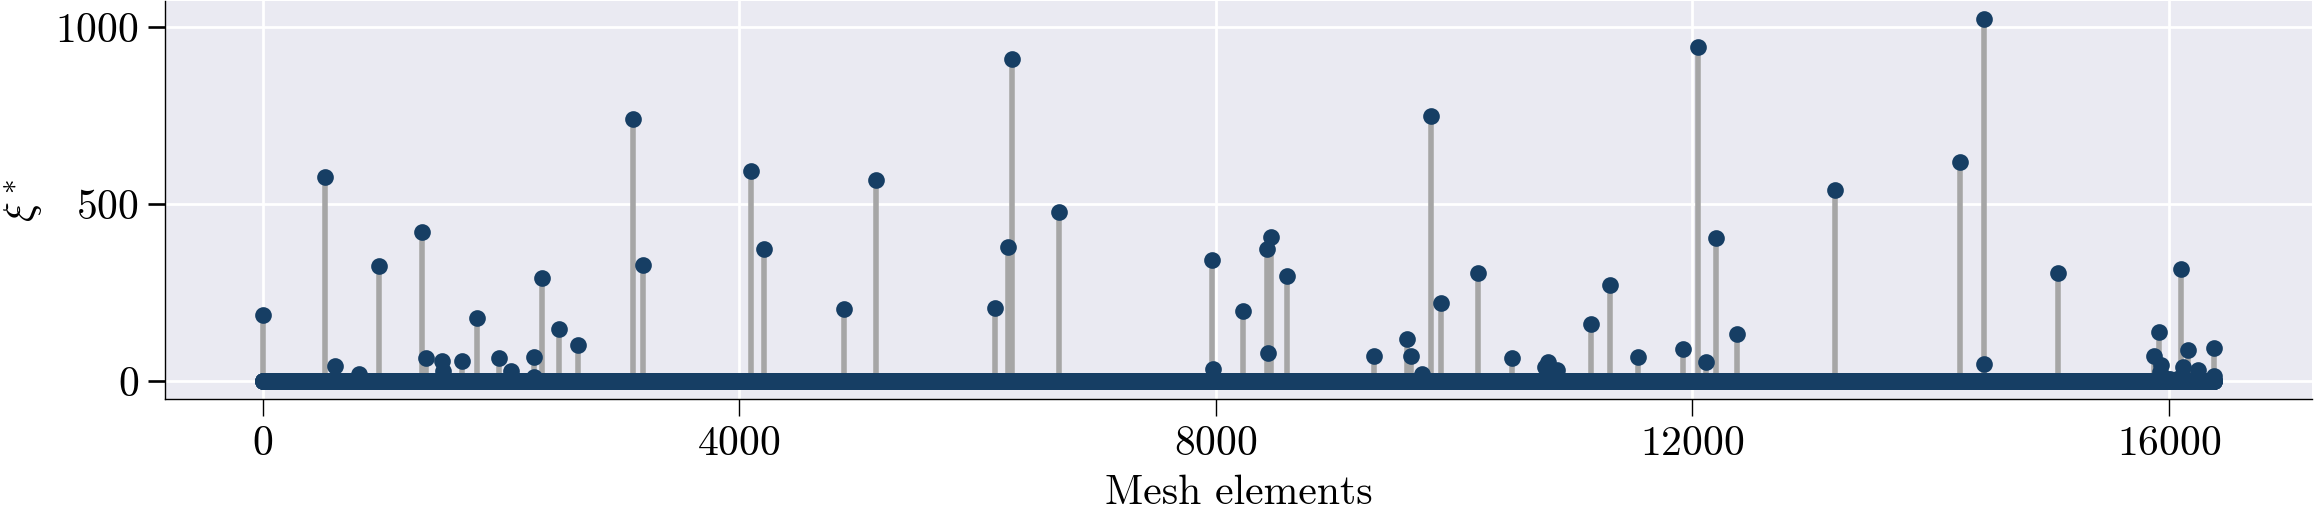

In [20]:
fig, ax = plot_ecsw_weights(x_nnls_m)

### Run HyperROM simulation


In [21]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
# rom will contain the hyper_rom solution as an attribute

rom.run_hyper_rom_simulation_ecsw(x_nnls_m)

Snap 1/32 params=[-5.97678427e+02  1.21865949e-01]
[Newton] Iter  0, step norm = 7.154e+03
[Newton] Iter  1, step norm = 1.169e+03
[Newton] Iter  2, step norm = 7.819e+01
[Newton] Iter  3, step norm = 3.110e-01
[Newton] Iter  4, step norm = 5.637e-06
Snap 2/32 params=[42.63963364  0.38449691]
[Newton] Iter  0, step norm = 8.406e+03
[Newton] Iter  1, step norm = 5.472e+03
[Newton] Iter  2, step norm = 8.583e+02
[Newton] Iter  3, step norm = 1.478e+01
[Newton] Iter  4, step norm = 4.406e-03
[Newton] Iter  5, step norm = 9.319e-09
Snap 3/32 params=[6.39479471e+02 2.15806173e-01]
[Newton] Iter  0, step norm = 3.920e+03
[Newton] Iter  1, step norm = 1.018e+03
[Newton] Iter  2, step norm = 3.990e+01
[Newton] Iter  3, step norm = 5.642e-02
[Newton] Iter  4, step norm = 1.131e-07
Snap 4/32 params=[-188.96433339    0.29058708]
[Newton] Iter  0, step norm = 1.665e+04
[Newton] Iter  1, step norm = 3.000e+03
[Newton] Iter  2, step norm = 3.043e+02
[Newton] Iter  3, step norm = 2.500e+00
[Newton] I

([0.19746034101805401,
  0.15303569215933857,
  0.17890702342072998,
  0.16644033503075223,
  0.1894160274845046,
  0.1606310261775801,
  0.22695999081360616,
  0.14079447921772295,
  0.17796175311517,
  0.16928517522481273,
  0.2107141371500552,
  0.14741886147789748,
  0.21261223849459046,
  0.14453419721942914,
  0.19130951533236715,
  0.15643037845093188,
  0.19618577307417165,
  0.15539131558845767,
  0.21860646531469588,
  0.14365966817694403,
  0.20510524769265961,
  0.14835531174806282,
  0.17395423655450368,
  0.17049820997181506,
  0.22029474269886956,
  0.14171729705016767,
  0.18481728293601848,
  0.16177690686789264,
  0.18328466529996218,
  0.16517174273593696,
  0.20271363131179979,
  0.1520084231239982],
 [59.06070284314227,
  60.861499165648524,
  77.5608591716334,
  77.66328742612673,
  74.94255627830478,
  75.64843207069265,
  2.2649445801184864,
  60.51568254481424,
  59.521230794316814,
  73.72763072845,
  118.68126525991053,
  89.31218743036547,
  91.2522101836888

In [22]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 4.3561e+00
Relative L2 Error:        1.5742e-03
L∞ Error:                 3.5886e-01
Relative L∞ Error:        1.4490e-03
RMSE:                     1.9251e-01
MAE:                      1.7349e-01

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0027

Error Distribution:
Median Error:             -1.5982e-01
95th Percentile Error:    3.1954e-01

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 5.5151e-05
Max Rel L2 Error over time/parameter: 7.0925e-05
Min Rel L2 Error over time/parameter: 4.3998e-05
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

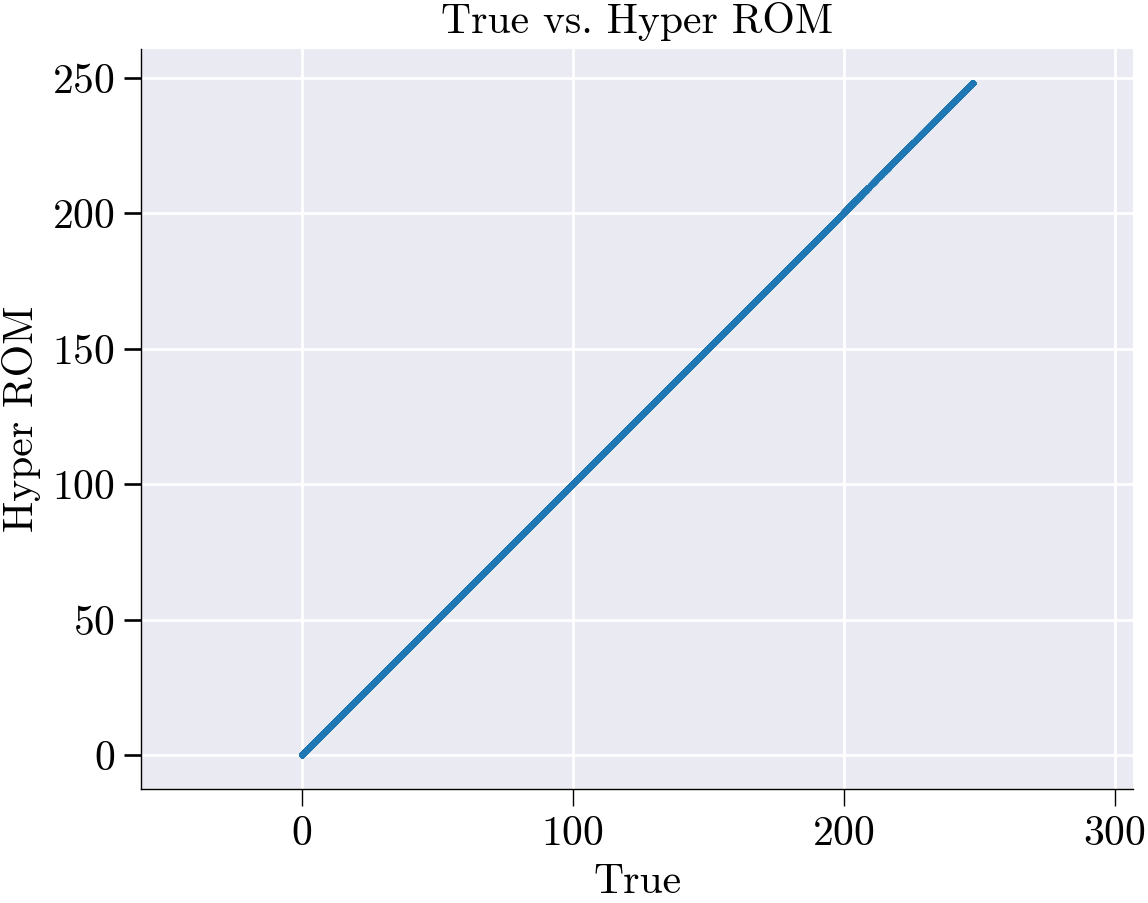

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


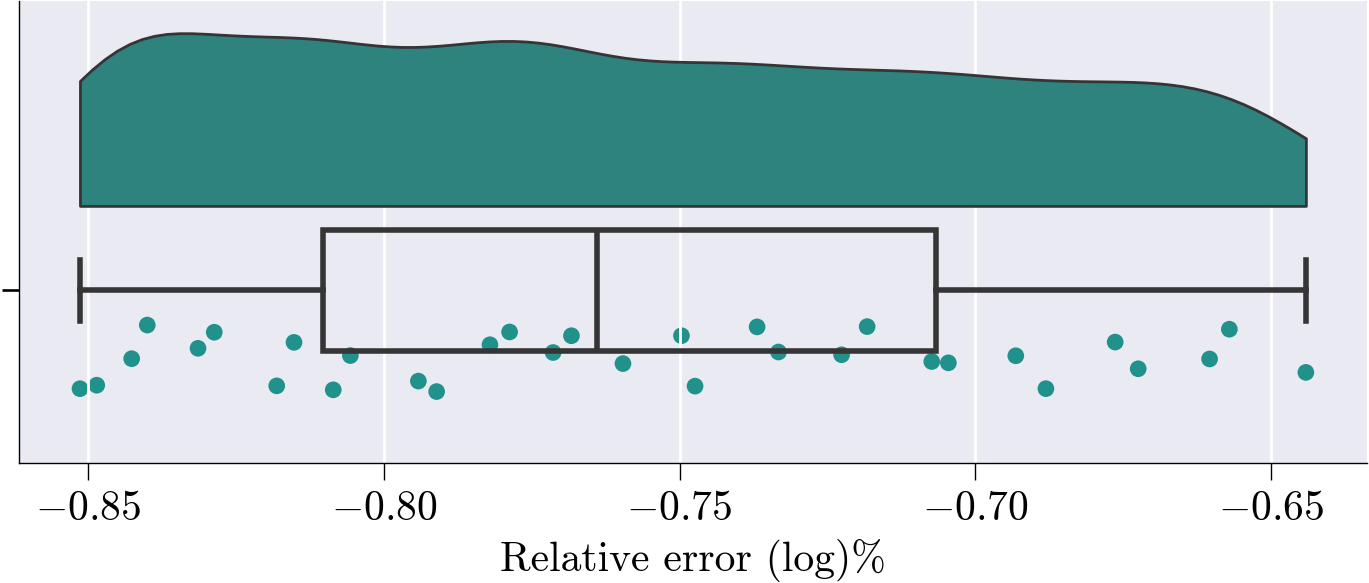

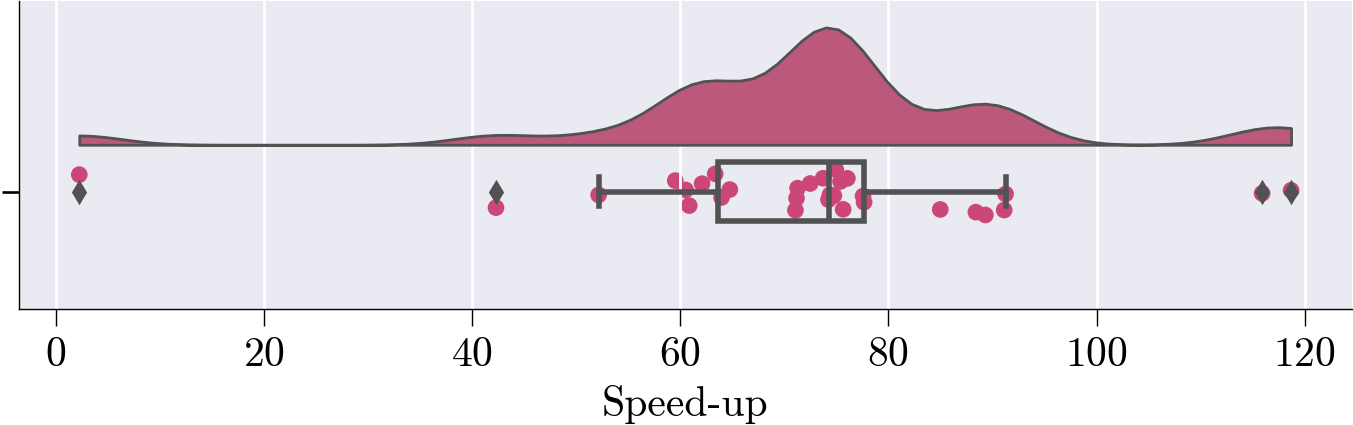

In [23]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

